# HW 1 Guide D: Constructing the Fama-French Factors

**Summary**

The Fama and French (1993) paper, "Common Risk Factors in the Returns on Stocks and Bonds," revolutionized asset pricing theory by challenging the Capital Asset Pricing Model (CAPM) with a three-factor model that includes market risk, size (market capitalization), and book-to-market value as predictors of stock returns. They demonstrated that the market factor alone does not fully explain stock returns and that small stocks and stocks with high book-to-market ratios yield higher returns than can be explained
by market beta alone, suggesting that these factors capture additional risks not accounted for by the CAPM. This seminal work has significantly influenced academic research and investment practices by highlighting the importance of size and value factors in asset pricing, thereby laying the groundwork for more sophisticated models and strategies in finance.

**Learning Outcomes**

1. **Work with CRSP and Compustat datasets**: Gain hands-on experience in using financial data sources that provide stock market prices and firm-level accounting data, which are essential for empirical research in finance.

2. **Leverage the CRSP/Compustat Merged (CCM) database**: Understand the purpose and structure of the CCM linking table, and use it to accurately merge CRSP’s market data with Compustat’s fundamental data.

3. **Construct Fama-French portfolios and factors**: Use market capitalization and book-to-market ratios to classify firms into portfolios, calculate value-weighted returns, and compute the size (SMB) and value (HML) factors.

4. **Compare your results with established benchmarks**: Validate your manually computed Fama-French factors against the official data from Kenneth French’s library and analyze any differences.


**Game Plan**

The code underlying this notebook follows the methodology described in https://wrds-www.wharton.upenn.edu/pages/wrds-research/applications/risk-factors-and-industry-benchmarks/fama-french-factors/ . I will quote from that methodology extensively. There is also a set
of videos on this linked website. Those may be helpful for this exercise.

The code is lightly edited from the code provided by WRDS on their website.

That code lives in `src/shared_portfolio_sorts.py` (the steps every
portfolio sort shares) and `src/calc_Fama_French_1993.py` (the size and
book-to-market sort and the factors). The `doit` tasks
`calc_Fama_French_1993` and `calc_inv_portfolios` run it, and
`calc_Fama_French_diagnostics` measures the result. This guide does not
rerun the pipeline. It looks at the raw data to explain each filter, then
loads what the tasks saved.

In [1]:
import pandas as pd

import calc_Fama_French_diagnostics
import figures
import pull_CRSP_Compustat
import pull_CRSP_stock
from settings import config

DATA_DIR = config("DATA_DIR")
OUTPUT_DIR = config("OUTPUT_DIR")

## Prep Data

### Step 1. Load Data

In order to replicate the factors from this paper, we need data from CRSP and Compustat. The CRSP data provides the stock prices while Compustat provides the fundamentals. We also use the CRSP/Compustat Linking Table to merge the two datasets. The merge is not straightforward, but there is a standard procedure used that is embodied in the linking table provided by CRSP and available on WRDS.

 - The **CRSP dataset** contains stock market data, including prices, returns, and shares outstanding, for securities traded on major U.S. exchanges. This dataset is essential for measuring market performance and calculating variables such as market equity.
 - The **Compustat dataset**, on the other hand, provides firm-level fundamental accounting data, such as book equity, revenue, and earnings, which are used to measure financial characteristics of companies.
 - Finally, the **CRSP/Compustat Linking Table (CCM)** acts as a bridge between these two datasets by mapping CRSP’s security identifiers (PERMNO, PERMCO) to Compustat’s firm identifiers (GVKEY). This linking table resolves complexities such as multiple securities per firm, corporate actions, and differing coverage periods, ensuring accurate integration of the datasets.

The `pull_CRSP_Compustat` task pulls all three; the loaders below read what it saved.

In [2]:
comp = pull_CRSP_Compustat.load_compustat(data_dir=DATA_DIR)
crsp = pull_CRSP_stock.load_CRSP_monthly_file(data_dir=DATA_DIR)
ccm = pull_CRSP_Compustat.load_CRSP_Comp_Link_Table(data_dir=DATA_DIR)

### Step 2. Calculate Book Equity

"We used Compustat XpressFeed (annual data) as the source of historical accounting data in order to calculate the value of Book Equity. Different from quarterly data, annual data is unrestated (ideal for backtesting). Book Equity is defined as the Compustat book value of stockholders' equity plus balance sheet deferred taxes and investment tax credit (if available) minus book value of preferred stock. We did not modify the original formula that adds deferred taxes and investment tax credit. According to Kenneth French's website (as of May 2018) , it had been changes to the treatment of deferred taxes described in FASB 109.

To estimate book value of preferred stock they use the redemption or liquidation or par value of preferred stock (in that order). Since Book Equity is almost missing for the whole sample during the 1950's, we constrained our sample to begin in 1960. Additionally, we created a variable that counts number of annual records in Compustat files."

The fallbacks for preferred stock exist because the preferred stock fields
are often missing. The share of missing values in each input shows how much
each fallback matters:

In [3]:
comp[["seq", "txditc", "pstkrv", "pstkl", "pstk"]].isna().mean().round(3)

seq       0.188
txditc    0.239
pstkrv    0.174
pstkl     0.170
pstk      0.175
dtype: float64

### Step 3. Subset CRSP to Common Stock and Proper Exchanges

NOTE: I am using the updates CIZ version of the CRSP flat file. This means that I don't have to merge the CRSP event files with the time series files and I don't need to apply delisting returns, as they are already applied.

"For the purpose of this procedure we used CRSP monthly data (users can extend this calculation to daily data). The first step in working with CRSP was to merge CRSP "event" and "time-series" files. CRSP event files contain historical information on the exchange code (crucial to identify firms listed in NYSE), share codes (to identify common stocks) and delisting returns. CRSP time-series files (as CRSP.MSF) contain information such as prices, returns and shares outstanding. We merged both files using a macro program (named ‘crspmerge')."

The CIZ format describes each security with several fields instead of one
share code. Counting their values in the pulled file shows what the
common-stock screen is choosing among:

In [4]:
crsp[["sharetype", "issuertype", "usincflg"]].value_counts().head(8)

sharetype  issuertype  usincflg
NS         CORP        Y           2775891
           ACOR        Y            661277
           CORP        N            241208
AD         CORP        N            149043
NS         REIT        Y             69397
UG         CORP        Y             41832
SB         REIT        Y             35195
AD         ACOR        N             19028
Name: count, dtype: int64

In [5]:
crsp["primaryexch"].value_counts()

primaryexch
Q    2167429
N    1287940
A     485932
X      64671
R        986
B        103
I         12
Name: count, dtype: Int64

Note that when we do this with the new CIZ format, we also need to apply the following filters:

**1. `conditionaltype = 'RW'`**

- Filters securities with a "Regular Way" trading status, indicating standard settlement transactions (typically T+2 for equities) without special conditions like halted or suspended trading.
- `RW` (Regular Way) ensures the security is traded under normal market operations.
- Excludes securities with conditional trading statuses (e.g., halted, suspended, or special settlement terms).

**2. `TradingStatusFlg = 'A'`**
- Identifies securities that are **actively trading** (not halted or suspended).
- `A` (Active) means the security is actively traded on the exchange during the period.
- Contrasts with flags like `H` (Halted) or `S` (Suspended), which indicate temporary trading interruptions.

In [6]:
crsp[["conditionaltype", "tradingstatusflg"]].value_counts().head(8)

conditionaltype  tradingstatusflg
RW               A                   3940193
NT               X                     64671
RW               H                      1120
                 S                       929
NW               A                       160
Name: count, dtype: int64

### Step 4.  Calculate Market Equity

NOTE: I am using the updates CIZ version of the CRSP flat file. This means that I don't have to merge the CRSP event files with the time series files and I don't need to apply delisting returns, as they are already applied.

"Second, we added delisting returns (to reduce any bias in portfolio returns) and calculated Market Capitalization (ME) for each CRSP security (abs(prc)*shrout). There were cases when the same firm (permco) had two or more securities (permno) on the same date. For the purpose of ME for the firm, we aggregated all ME for a given permco, date. This aggregated ME was assigned to the CRSP permno that has the largest ME. Finally, ME at June and December were flagged since (1) December ME will be used to create Book-to-Market ratio (BEME) and (2) June ME has to be positive in order to be part of the portfolio."

How common is a firm with more than one security? Count the securities
(`permno`) per firm (`permco`) in each month:

In [7]:
crsp.groupby(["permco", "jdate"])["permno"].nunique().value_counts().head()

permno
1    3927376
2      37666
3        846
4        153
7        100
Name: count, dtype: int64

### Step 5. Merge CRSP and Compustat

#### What is the CRSP/Compustat Merged (CCM) database?

To successfully replicate the Fama-French factors, we need to merge the CRSP and Compustat datasets. This step is not straightforward due to the differences in their data structures, coverage, and primary identifiers. CRSP data primarily tracks securities, while Compustat focuses on firm-level accounting data, making it necessary to carefully link the two. Luckily, we have access to the **CRSP/Compustat Merged (CCM) database**, which serves as an intermediary table designed to simplify the merging process by providing pre-established links between the datasets.

It is important to note that the CCM database is not a direct merging of the CRSP and Compustat datasets. Instead, it is a linking table that matches CRSP identifiers (such as PERMNO and PERMCO) with Compustat's GVKEY identifier. By leveraging CCM, we can handle complexities such as companies with multiple securities, historical changes due to mergers and acquisitions, and discrepancies in data coverage between the two datasets. For example, the linking table includes fields to identify "primary" matches (e.g., `linkprim = 'P'`) and remove duplicate or ambiguous links, ensuring the integrity of the merged data.

The CCM database is critical because it eliminates the need to manually match identifiers across datasets, a process that can be error-prone and time-consuming. Using CCM ensures that we can accurately align CRSP’s market data with Compustat’s fundamental data, allowing us to calculate variables like the book-to-market ratio and market capitalization, which are essential for constructing Fama-French portfolios and factors. In this step, we will merge the datasets using CCM while cleaning the data to handle duplicates and ambiguities, laying the foundation for the next steps in the analysis.

In summary, the CCM provides link identifiers between CRSP's PERMNO/PERMCO and Compustat's GVKEY. This linking is complex because:

 - Companies can have multiple securities (PERMNOs)
 - Companies merge, split, or change names
 - Corporate structures change over time

The CCM database handles these complexities for us.

#### Continuing with the methodology

Following along with the linked methodology from above,


> "We merged CRSP and Compustat using the CRSP CCM product (as of April 2010). We matched Compustat's gvkey (from calendar year t-1) to CRSP's permno as of June year t. Data was cleaned for unnecessary duplicates. First there were cases when different gvkeys exist for same permno-date. We solved these duplicates by only keeping those cases that are flagged as 'primary' matches by CRSP's CCM (linkprim='P' ). There were other unnecessary duplicates that were removed. Some companies may have two annual accounting records in the same calendar year. This is produced by change in the fiscal year end during the same calendar year. In these cases, we selected the last annual record for a given calendar year.

> After data cleaning, the book-to-market ratio for every firm in the sample were calculated by dividing Book Equity (for fiscal year that ends on year t-1) over the market value of its common equity at the end of December year t -1. These book-to-market ratios and Market Capitalization (as of December year t-1) were assigned to June year t in order to create portfolios."

## How much of the sample survives each step

Each filter above removes observations. The `calc_Fama_French_diagnostics`
task counts what is left after each step of the pipeline, using the same
functions that build the portfolios. The unit changes along the way: Compustat
is one row per firm-year, the CRSP monthly file one row per stock-month, and
the June files one row per stock per June.

In [8]:
attrition, ff_compare, inv_compare = calc_Fama_French_diagnostics.load_diagnostics(
    output_dir=OUTPUT_DIR
)
attrition

,Dataset,Step,Unit,Observations,Distinct IDs,ID
0,Compustat,"Annual fundamentals, as pulled",firm-year,592717,46823,gvkey
1,Compustat,With positive book equity,firm-year,431354,35346,gvkey
2,CRSP,"Monthly stock file, as pulled",stock-month,4007073,31003,permno
3,CRSP,"Common stock on NYSE, AMEX, and Nasdaq",stock-month,3375612,26040,permno
4,CRSP,One security per firm (largest permno in permco),stock-month,3340748,25910,permno
5,CRSP,June observations with a prior-December ME,stock-June,267285,24901,permno
6,CRSP-Compustat,June observations linked through CCM,stock-June,251462,22165,permno
7,CRSP-Compustat,Held in one of the six portfolios,stock-month,2647979,21038,permno


Three steps do most of the work. Requiring positive book equity drops about a
quarter of Compustat firm-years. The common-stock and exchange screen drops
ADRs, REITs, foreign-incorporated firms, and securities that trade off the
three main exchanges. And moving from monthly data to June observations is a
change of unit, not a loss: each stock contributes one June per year, which
is when portfolios are formed.

## Create Portfolios and Factors

### Step 6. Create Portfolios by Size and Book-to-Market.

"Every June (year t) we calculated the median equity value of NYSE-listed firms using Market Capitalization at June t. We used this median to classify firms as Small or Big on portfolios created at the end of June year t. In a similar fashion, as of June year t, firms are broken into three book-to-market equity groups (Low, Medium, and High) based on the 30% and 70% break-points of the NYSE-firms with positive book-to-market equity. In both cases (for size and book-to-market classification), we restricted our sample to those firms with positive book-to-market, positive market cap at June, common equity (share code 10 and 11) and at least two years in Compustat annual file.

We created a total of six size and book-to-market equity portfolios. Portfolios are created at the end of June and kept for 12 months. Within each portfolio a monthly value-weighted return is calculated (each month, the weight is the Market Capitalization as of June year t adjusted by any change in price between the end June t and the end of the previous month)."

![Fama-French Portfolio Splits](./assets/fama_french_portfolio_splits.gif)

The number of firms in each portfolio shows how the sort evolves. The jump in
the early 1970s is Nasdaq entering CRSP. Because the breakpoints come from
NYSE firms only, the small-firm portfolios absorb most of the Nasdaq listings.

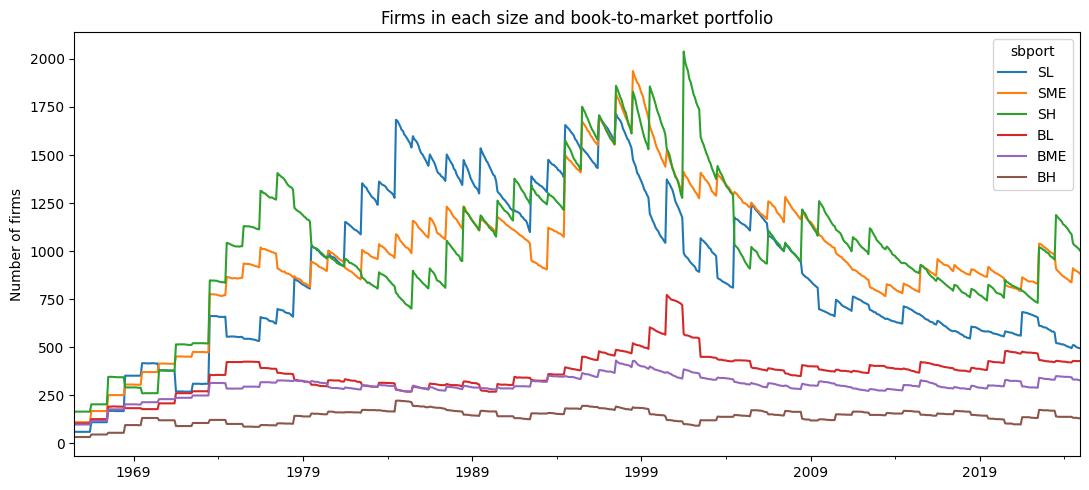

In [9]:
vwret_n = pd.read_parquet(DATA_DIR / "FF_1993_vwret_n.parquet")
fig = figures.plot_portfolio_firm_counts(vwret_n)

### Step 7. Calculation of FF factors

"The size factor, Small minus Big (SMB) , is the difference of average return on the three Small-firm portfolios and the average return on the three Big-firm portfolios.

The value factor, High minus Low (HML) , is the difference between the average return on the two High book-to-market equity portfolios and the average return on the two Low book-to-market equity portfolios. For comparison purpose, we also calculate the number of firms in each portfolio."

## Compare with Ken French's factors

The test of the whole pipeline is whether the SMB and HML it builds from raw
CRSP and Compustat data match the factors Ken French publishes. The
correlations, from 1970 on:

In [10]:
ff_compare.corr().round(3)

,smb_actual,hml_actual,smb_manual,hml_manual
smb_actual,1.000,-0.149,0.996,-0.196
hml_actual,-0.149,1.000,-0.134,0.984
smb_manual,0.996,-0.134,1.000,-0.192
hml_manual,-0.196,0.984,-0.192,1.000


Plotting cumulative returns makes small, persistent differences visible,
which a correlation can hide:

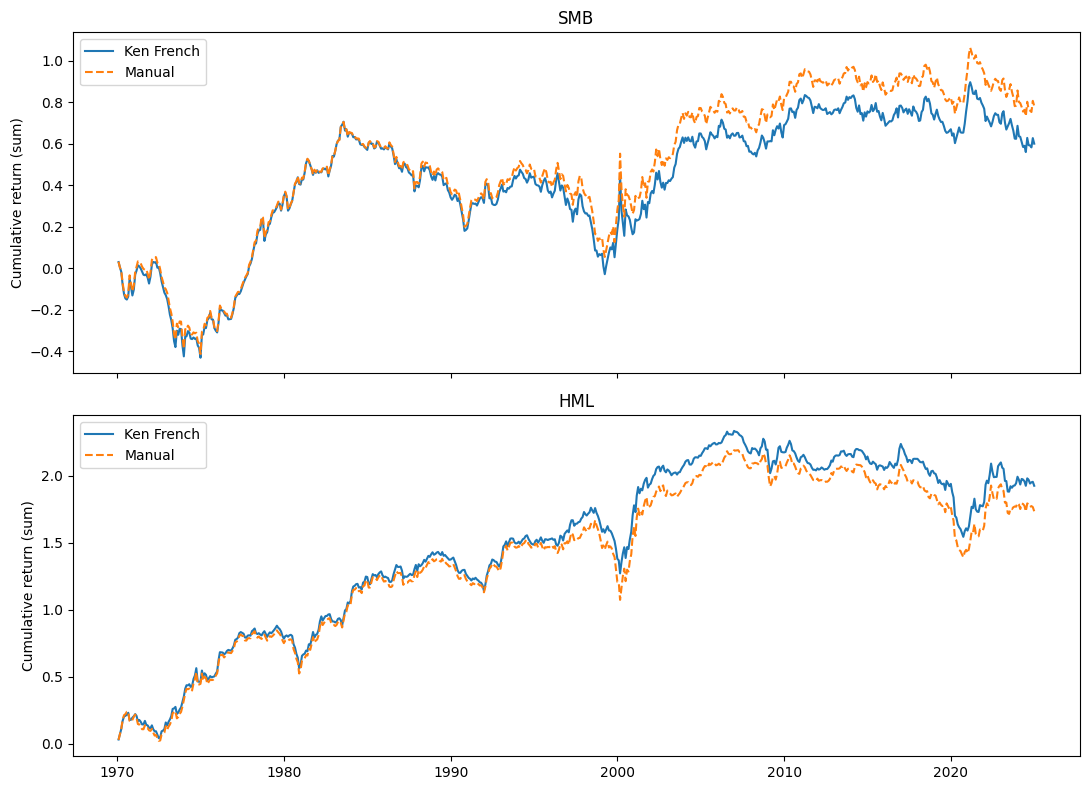

In [11]:
fig = figures.plot_factor_comparison(ff_compare)

The match is close but not exact. The differences come from data vintages
(Compustat and CRSP revise history), from the move to the CIZ version of
CRSP, and from small screening choices that the published methodology does
not pin down. The tests in `src/test_calc_Fama_French_1993.py` check for this
kind of statistical closeness, not for an exact match.

## The investment sort

The same machinery builds a second sort, on corporate investment, as in the
five-factor model of Fama and French (2015). Investment is asset growth: the
change in total assets from fiscal year $t-2$ to $t-1$, divided by total
assets in $t-2$. Each June, the 30th and 70th percentiles of investment among
NYSE firms split all stocks into Low (conservative), Medium, and High
(aggressive) portfolios, held from July to the next June.

Everything up to the merge with Compustat is shared with the size and
book-to-market sort: the same book equity, market equity, and universe
screens. Only the sorting variable and its breakpoints are new, which is why
`src/calc_inv_portfolios.py` is short. Its portfolios track Ken French's
"Portfolios Formed on INV" closely:

In [12]:
inv_compare.round(3)

,Pearson R
High,0.981
Low,0.958
Medium,0.982
